# 🧠 AI-Based Autonomous Navigation System
## Notebook 2 — Perception Pipeline
### YOLOv8 Object Detection + Classical Lane Detection

**What you'll learn:**
1. How to run YOLOv8 inference on any image
2. How lane detection works (Canny + Hough transform)
3. How both outputs feed into the navigation system
4. How to visualize detection results like a real AV stack

---

In [1]:
# Setup: Add project root to sys.path
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json

print('✅ Imports ready')

✅ Imports ready


## Part A — YOLOv8 Object Detection

In [ ]:
# ──────────────────────────────────────────────
# A1: Load the YOLO detector
# ──────────────────────────────────────────────
from src.perception.yolo_detector import YOLODetector

detector = YOLODetector()
print('YOLODetector ready.')
print(f'  Model       : {detector.model.model_name if hasattr(detector.model, "model_name") else "yolov8n"}')
print(f'  Confidence  : {detector.confidence_threshold}')
print(f'  Obs. classes: {sorted(detector.obstacle_classes)}')

[YOLODetector] Loading model: yolov8n.pt
[YOLODetector] ✅ Model ready.
YOLODetector ready.
  Model       : yolov8n.pt
  Confidence  : 0.4
  Obs. classes: [0, 1, 2, 5, 7, 9, 11]


✅ Loaded real image: bus.jpg  (810×1080)


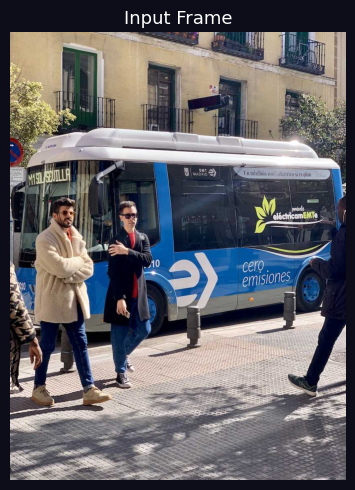

In [3]:
# ──────────────────────────────────────────────
# A2: Create a synthetic demo frame (fallback if no real image)
#     — draws mock bounding boxes from sample data
# ──────────────────────────────────────────────

# Try to load a real image first
frame = None
test_dir = os.path.join(project_root, 'assets', 'test_frames')
if os.path.exists(test_dir):
    for fname in os.listdir(test_dir):
        img_path = os.path.join(test_dir, fname)
        frame = cv2.imread(img_path)
        if frame is not None:
            print(f'✅ Loaded real image: {fname}  ({frame.shape[1]}×{frame.shape[0]})')
            break

# Fallback: create a synthetic street-like image
if frame is None:
    print('ℹ️  No real image found — creating synthetic frame')
    frame = np.zeros((480, 640, 3), dtype=np.uint8)
    # Road background
    frame[:] = (60, 60, 70)
    # Road lanes
    frame[240:480, :] = (40, 40, 50)
    # Lane markings
    for x in range(50, 640, 80):
        cv2.rectangle(frame, (x, 355), (x+40, 365), (220, 200, 50), -1)
    cv2.putText(frame, 'SYNTHETIC FRAME (no image in assets/test_frames)',
                (30, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Input Frame', color='white', fontsize=13)
plt.axis('off')
plt.gca().set_facecolor('#0d0d1a')
plt.gcf().set_facecolor('#0d0d1a')
plt.tight_layout()
plt.show()

In [4]:
# ──────────────────────────────────────────────
# A3: Run YOLO detection
# ──────────────────────────────────────────────
print('Running YOLOv8 inference...')
detections = detector.detect(frame)

print(f'\n🔍 Detections found: {len(detections)}')
print('─' * 60)
for i, d in enumerate(detections):
    x1,y1,x2,y2 = d['bbox']
    print(f"  [{i+1}] {d['label']:<14} conf={d['conf']:.2f}  "
          f"bbox=({x1},{y1})→({x2},{y2})")

if len(detections) == 0:
    print('  [No obstacles detected in this frame]')
    print('  ✅ System will use simulation obstacles from ObstacleManager')

Running YOLOv8 inference...

🔍 Detections found: 4
────────────────────────────────────────────────────────────
  [1] bus            conf=0.87  bbox=(22,231)→(805,756)
  [2] person         conf=0.87  bbox=(48,398)→(245,902)
  [3] person         conf=0.85  bbox=(669,392)→(809,877)
  [4] person         conf=0.83  bbox=(221,405)→(344,857)


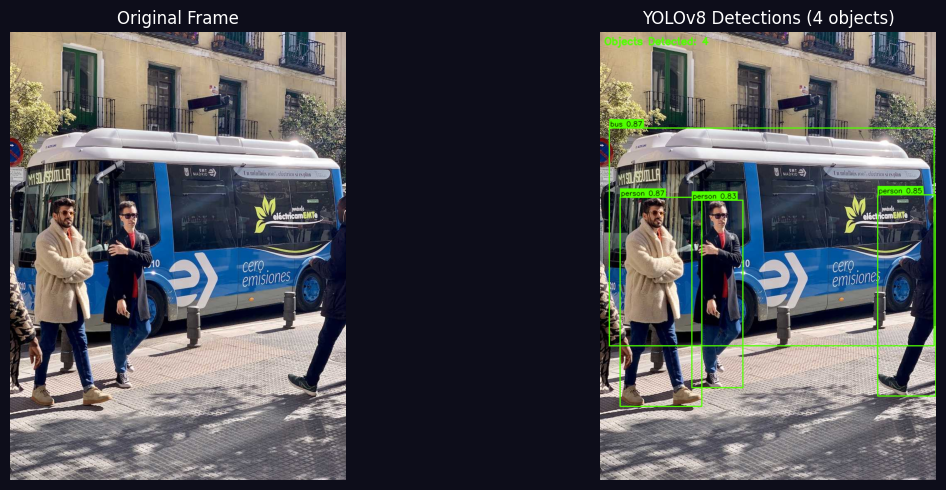

Saved → outputs/screenshots/yolo_detections.png


In [5]:
# ──────────────────────────────────────────────
# A4: Draw detections + show annotated frame
# ──────────────────────────────────────────────
annotated = detector.draw_detections(frame.copy(), detections)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d1a')

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame', color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'YOLOv8 Detections ({len(detections)} objects)', color='white', fontsize=12)
axes[1].axis('off')

for ax in axes:
    ax.set_facecolor('#0d0d1a')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'yolo_detections.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved → outputs/screenshots/yolo_detections.png')

In [6]:
# ──────────────────────────────────────────────
# A5: Show detection statistics from sample_obstacles.json
# ──────────────────────────────────────────────
import pandas as pd

json_path = os.path.join(project_root, 'data', 'sample_obstacles.json')
with open(json_path) as f:
    sample_detections = json.load(f)

df = pd.DataFrame(sample_detections)
df['width']  = df['x2'] - df['x1']
df['height'] = df['y2'] - df['y1']
df['area']   = df['width'] * df['height']

display_cols = ['id', 'label', 'confidence', 'cx', 'cy', 'width', 'height', 'area']
print('Sample Obstacle Detection Data:')
df[display_cols]

Sample Obstacle Detection Data:


,id,label,confidence,cx,cy,width,height,area
0,1,person,0.92,300,320,50,80,4000
1,2,car,0.87,500,280,80,50,4000
2,3,stop sign,0.95,660,100,40,40,1600
3,4,bicycle,0.78,380,500,50,55,2750
4,5,truck,0.83,200,320,90,65,5850
5,6,traffic light,0.91,820,280,24,40,960


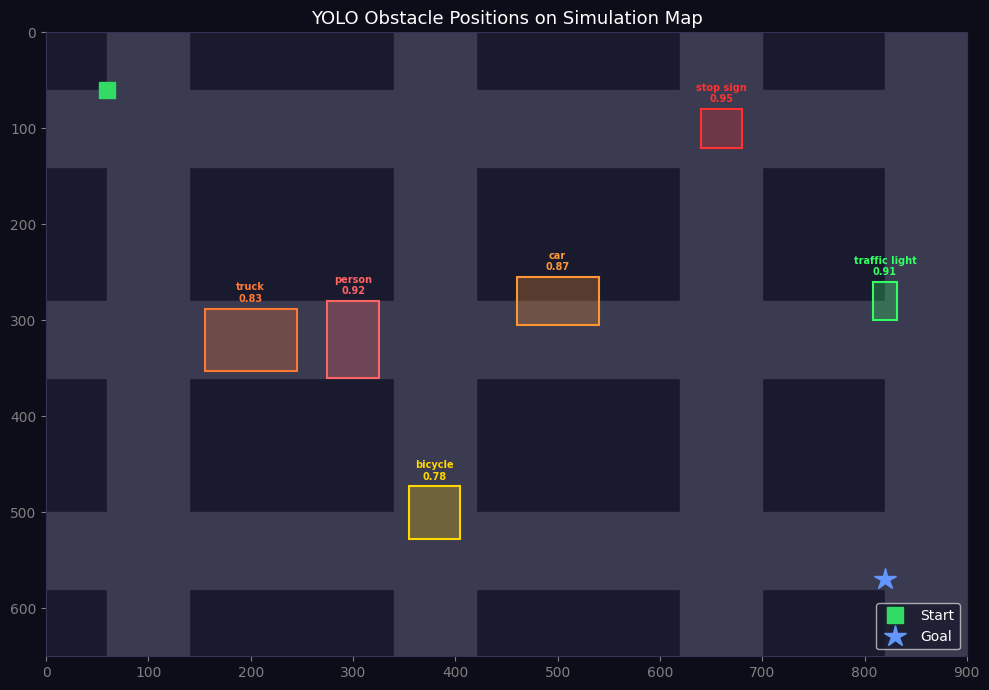

In [7]:
# ──────────────────────────────────────────────
# A6: Visualize sample obstacle positions on a map
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#1a1a2e')

# Draw road grid (simplified)
road_color = '#3a3a50'
for rx, ry, rw, rh in [(0,60,900,80),(0,280,900,80),(0,500,900,80),
                         (60,0,80,650),(340,0,80,650),(620,0,80,650),(820,0,80,650)]:
    ax.add_patch(patches.Rectangle((rx, ry), rw, rh, color=road_color))

# Draw obstacles from sample data
colors = {'person':'#ff6464','car':'#ff9632','bicycle':'#ffd700',
           'stop sign':'#ff3232','truck':'#ff7832','traffic light':'#32ff64'}

for obs in sample_detections:
    cx, cy = obs['cx'], obs['cy']
    w  = obs['x2'] - obs['x1']
    h  = obs['y2'] - obs['y1']
    color = colors.get(obs['label'], '#ffffff')
    rect = patches.Rectangle((cx-w//2, cy-h//2), w, h,
                               linewidth=1.5, edgecolor=color, facecolor=color+'44')
    ax.add_patch(rect)
    ax.text(cx, cy-h//2-5, f"{obs['label']}\n{obs['confidence']:.2f}",
            ha='center', va='bottom', fontsize=7, color=color, fontweight='bold')

# Start / Goal markers
ax.plot(60, 60, 's', color='#32dc64', ms=12, label='Start')
ax.plot(820, 570, '*', color='#6496ff', ms=16, label='Goal')

ax.set_xlim(0, 900)
ax.set_ylim(650, 0)  # Invert Y to match Pygame
ax.set_title('YOLO Obstacle Positions on Simulation Map', color='white', fontsize=13)
ax.legend(loc='lower right', facecolor='#1a1a2e', labelcolor='white')
ax.tick_params(colors='gray')
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'obstacle_map.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## Part B — Lane Detection (Classical CV Pipeline)

In [8]:
# ──────────────────────────────────────────────
# B1: Load lane detector
# ──────────────────────────────────────────────
from src.perception.lane_detector import LaneDetector

lane_detector = LaneDetector()
print(f'LaneDetector ready')
print(f'  Canny edge  : {lane_detector.threshold} threshold')
print(f'  Hough rho   : {lane_detector.rho}')
print(f'  Min length  : {lane_detector.min_len}px')

LaneDetector ready
  Canny edge  : 40 threshold
  Hough rho   : 1
  Min length  : 40px


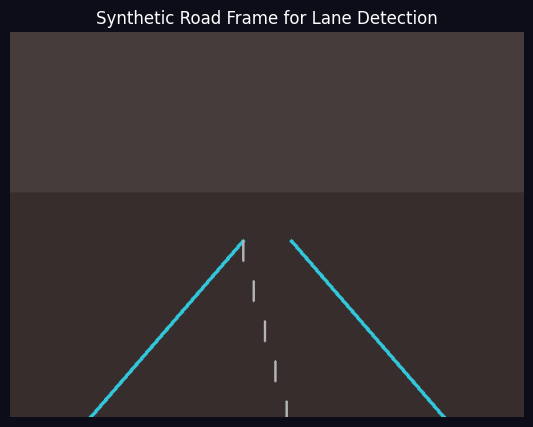

In [13]:
# ──────────────────────────────────────────────
# B2: Build a synthetic road image for lane detection demo
# ──────────────────────────────────────────────
road_img = np.zeros((480, 640, 3), dtype=np.uint8)
road_img[:] = (60, 60, 70)          # sky/environment
road_img[200:, :] = (45, 45, 55)    # road surface

# Perspective lane lines (drawn slightly narrower to fit inside the ROI mask)
cv2.line(road_img, (290, 260), (100, 480), (220, 200, 50), 4)
cv2.line(road_img, (350, 260), (540, 480), (220, 200, 50), 4)

# Dashed center line
for y in range(260, 480, 50):
    center_x = int(290 + (350 - 290) * (y - 260) / (480 - 260))
    cv2.line(road_img, (center_x, y), (center_x, y+25), (180, 180, 180), 2)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(road_img, cv2.COLOR_BGR2RGB))
plt.title('Synthetic Road Frame for Lane Detection', color='white')
plt.axis('off')
plt.gca().set_facecolor('#0d0d1a')
plt.gcf().set_facecolor('#0d0d1a')
plt.show()

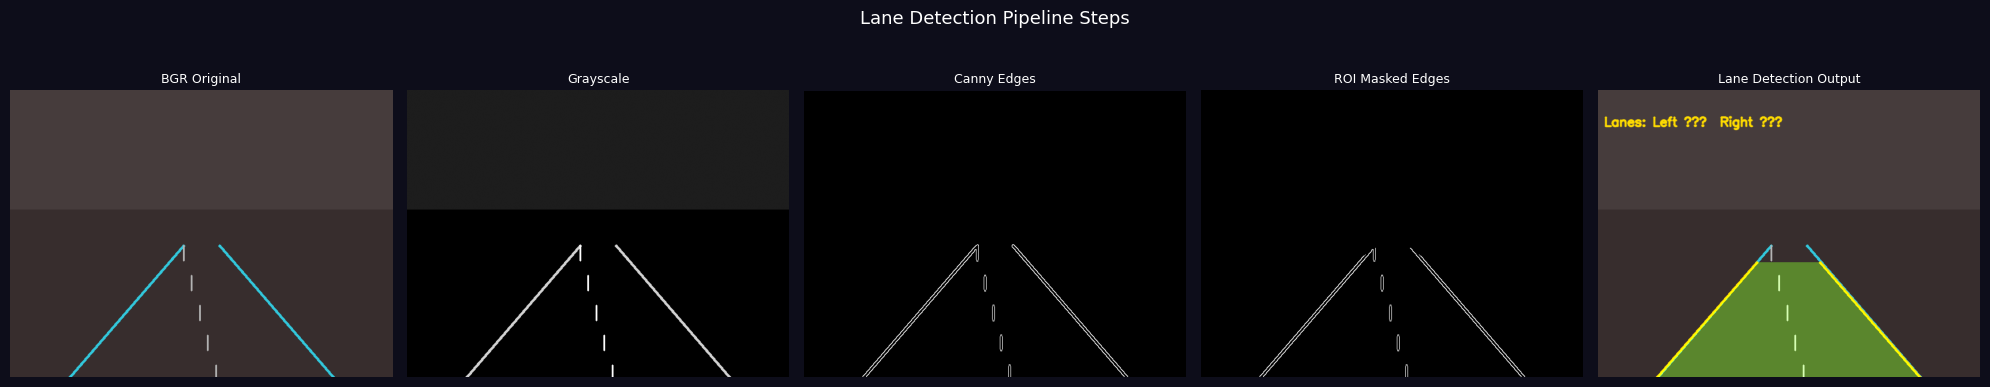


Lane Detection Results:
  Left lane  : (99, 480, 266, 288)
  Right lane : (539, 480, 372, 288)


In [14]:
# ──────────────────────────────────────────────
# B3: Run the full lane detection pipeline — step by step
# ──────────────────────────────────────────────
gray    = cv2.cvtColor(road_img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges   = cv2.Canny(blurred, 50, 150)

# ROI mask
h, w = edges.shape
mask = np.zeros_like(edges)
poly = np.array([[
    (int(w * 0.05), h), (int(w * 0.45), int(h * 0.55)),
    (int(w * 0.55), int(h * 0.55)), (int(w * 0.95), h),
]], dtype=np.int32)
cv2.fillPoly(mask, poly, 255)
roi_edges = cv2.bitwise_and(edges, mask)

# Full detection
annotated_lane, lanes = lane_detector.detect(road_img)

# Display all pipeline stages
stages = [
    (road_img,      'BGR Original',        'None'),
    (gray,          'Grayscale',            'gray'),
    (edges,         'Canny Edges',          'gray'),
    (roi_edges,     'ROI Masked Edges',     'gray'),
    (annotated_lane,'Lane Detection Output','None'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.patch.set_facecolor('#0d0d1a')

for ax, (img, title, cmap) in zip(axes, stages):
    if cmap == 'gray':
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, color='white', fontsize=9)
    ax.axis('off')
    ax.set_facecolor('#0d0d1a')

plt.suptitle('Lane Detection Pipeline Steps', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'screenshots', 'lane_pipeline.png'),
            dpi=120, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

print(f'\nLane Detection Results:')
print(f'  Left lane  : {lanes["left"]}')
print(f'  Right lane : {lanes["right"]}')

In [11]:
# ──────────────────────────────────────────────
# B4: How lane data connects to navigation
# ──────────────────────────────────────────────
def compute_lane_center(left_lane, right_lane, frame_width):
    """Estimate the center of the drivable lane."""
    if left_lane is None and right_lane is None:
        return frame_width // 2, 'UNKNOWN'
    if left_lane is None:
        return right_lane[0] - 60, 'RIGHT ONLY'
    if right_lane is None:
        return left_lane[0] + 60, 'LEFT ONLY'
    center_x = (left_lane[0] + right_lane[0]) // 2
    return center_x, 'BOTH'

center_x, status = compute_lane_center(lanes['left'], lanes['right'], w)
print(f'Lane Status    : {status}')
print(f'Lane Center X  : {center_x} px')
print(f'Frame Width    : {w} px')
print(f'Lateral Offset : {center_x - w//2:+d} px from image center')
if abs(center_x - w//2) > 50:
    print('⚠️  Car is significantly off-center — steering correction needed')
else:
    print('✅  Car is within lane bounds')

Lane Status    : UNKNOWN
Lane Center X  : 320 px
Frame Width    : 640 px
Lateral Offset : +0 px from image center
✅  Car is within lane bounds


---
## Part C — Threat Assessment (ObstacleDetector)


In [12]:
# ──────────────────────────────────────────────
# C1: Demonstrate proximity threat assessment
# ──────────────────────────────────────────────
from src.perception.obstacle_detector import ObstacleDetector

od = ObstacleDetector()

# Load centroids from sample data
centroids = [(obs['cx'], obs['cy']) for obs in sample_detections]
od.update_obstacles(centroids)

# Test from multiple car positions
test_positions = [(100, 100), (300, 310), (500, 300), (650, 120)]

print('Threat Assessment at Different Car Positions:')
print('─' * 65)
for car_x, car_y in test_positions:
    reports = od.assess(car_x, car_y)
    threat  = od.nearest_threat_level(car_x, car_y)
    emoji   = {'CLEAR': '🟢', 'WARNING': '🟡', 'DANGER': '🔴'}.get(threat, '⚪')
    print(f'  Car at ({car_x:3d},{car_y:3d})  →  {emoji} {threat:8s}  '
          f'({len(reports)} obstacles in sensor range)')
    for r in reports[:2]:   # show top 2
        print(f'           obstacle at {r["pos"]}  dist={r["dist"]}px  {r["threat"]}')

Threat Assessment at Different Car Positions:
─────────────────────────────────────────────────────────────────
  Car at (100,100)  →  🟢 CLEAR     (0 obstacles in sensor range)
  Car at (300,310)  →  🔴 DANGER    (1 obstacles in sensor range)
           obstacle at (300, 320)  dist=10.0px  DANGER
  Car at (500,300)  →  🔴 DANGER    (1 obstacles in sensor range)
           obstacle at (500, 280)  dist=20.0px  DANGER
  Car at (650,120)  →  🔴 DANGER    (1 obstacles in sensor range)
           obstacle at (660, 100)  dist=22.4px  DANGER


---
### ➡️ Next Notebook
Open **`03_path_planning_demo.ipynb`** to visualize A* path planning, obstacle inflation, and FSM state transitions.